In [55]:
import matplotlib
import pickle
from matplotlib import pyplot as plt
import numpy as np
import seaborn as sb
from scipy import stats
from scipy.stats import binom
import datetime
import statistics
import multiprocess as mp
import time
import arviz as az

from epydemix import EpiModel
from epydemix import load_predefined_model
from epydemix.visualization import plot_quantiles, plot_trajectories, plot_posterior_distribution_2d, plot_distance_distribution
from epydemix.population import load_epydemix_population, Population, get_available_locations
from epydemix.visualization import plot_contact_matrix, plot_population
from epydemix.utils import compute_simulation_dates
from epydemix import simulate
from epydemix.calibration import ABCSampler, rmse, wmape, ae, mae, mape
import matplotlib.pyplot as plt
import pandas as pd
from epydemix.visualization import plot_posterior_distribution

from Epy_functions import stochastic_sir, stochastic_sir_noisy, summary, weighted_ess


# Simulation

In [56]:
N = 10000
I0 = 10

In [57]:
# Simulate an epidemic with full observations (incidence data) 
model = stochastic_sir(0.45, 0.08, N, I0, 100)

In [58]:
# Isolate the observations
incidence_observed = (model['incidence'])

# Create DataFrame of observations (this is what Epydemix accepts)
incidence_df = pd.DataFrame(incidence_observed)
incidence_df = incidence_df.rename(columns={0: 'data'})
incidence_df['date'] = pd.date_range(start = '2024/01/01', periods = len(incidence_df), freq='D')

# ABC-SMC Calibration

In [59]:
# Priors
priors = {"beta": stats.gamma(4.5, scale = 0.1), 
          "gamma": stats.gamma(8, scale = .01)}

# Simulation parameters
parameters = {'N': N,
              'n_i': I0,
              'timesteps': 100}

# Wrapper function
def simulate_wrapper(parameters):
    results = stochastic_sir(**parameters)
    return{'data': results['incidence']}

## RMSE

In [60]:
# Initialize the ABCSampler object
abc_sampler_rmse = ABCSampler(simulation_function=simulate_wrapper,
                         priors = priors,
                         parameters=parameters,
                         observed_data=incidence_observed)

In [61]:
def smc_calibrate_rmse(seed):
    np.random.seed(seed)
    results_smc = abc_sampler_rmse.calibrate(strategy='smc',
                                    num_particles=1000,
                                    num_generations=9,
                                    )
    return results_smc

In [62]:
results_rmse = smc_calibrate_rmse(1)

Starting ABC-SMC with 1000 particles and 9 generations

Generation 1/9 (epsilon: inf)
	Accepted 1000/1000 (acceptance rate: 100.00%)
	Elapsed time: 00:00:00

Generation 2/9 (epsilon: 203.833731)
	Accepted 1000/4016 (acceptance rate: 24.90%)
	Elapsed time: 00:00:02

Generation 3/9 (epsilon: 112.868753)
	Accepted 1000/7060 (acceptance rate: 14.16%)
	Elapsed time: 00:00:02

Generation 4/9 (epsilon: 61.444198)
	Accepted 1000/11302 (acceptance rate: 8.85%)
	Elapsed time: 00:00:02

Generation 5/9 (epsilon: 38.510770)
	Accepted 1000/18436 (acceptance rate: 5.42%)
	Elapsed time: 00:00:03

Generation 6/9 (epsilon: 26.467432)
	Accepted 1000/30422 (acceptance rate: 3.29%)
	Elapsed time: 00:00:03

Generation 7/9 (epsilon: 20.486819)
	Accepted 1000/51716 (acceptance rate: 1.93%)
	Elapsed time: 00:00:05

Generation 8/9 (epsilon: 17.345172)
	Accepted 1000/94822 (acceptance rate: 1.05%)
	Elapsed time: 00:00:08

Generation 9/9 (epsilon: 15.514832)
	Accepted 1000/170942 (acceptance rate: 0.58%)
	Elapsed

## WMAPE

In [63]:
# Initialize the ABCSampler object
abc_sampler_wmape = ABCSampler(simulation_function=simulate_wrapper,
                         priors = priors,
                         parameters=parameters,
                         observed_data=incidence_observed,
                         distance_function = wmape)

In [64]:
def smc_calibrate_wmape(seed):
    np.random.seed(seed)
    results_smc = abc_sampler_wmape.calibrate(strategy='smc',
                                    num_particles=1000,
                                    num_generations=9,
                                    )
    return results_smc

In [65]:
results_wmape = smc_calibrate_wmape(1)

Starting ABC-SMC with 1000 particles and 9 generations

Generation 1/9 (epsilon: inf)
	Accepted 1000/1000 (acceptance rate: 100.00%)
	Elapsed time: 00:00:00

Generation 2/9 (epsilon: 1.016064)
	Accepted 1000/3618 (acceptance rate: 27.64%)
	Elapsed time: 00:00:02

Generation 3/9 (epsilon: 0.677259)
	Accepted 1000/7584 (acceptance rate: 13.19%)
	Elapsed time: 00:00:02

Generation 4/9 (epsilon: 0.358936)
	Accepted 1000/11369 (acceptance rate: 8.80%)
	Elapsed time: 00:00:02

Generation 5/9 (epsilon: 0.214910)
	Accepted 1000/17600 (acceptance rate: 5.68%)
	Elapsed time: 00:00:03

Generation 6/9 (epsilon: 0.144578)
	Accepted 1000/27401 (acceptance rate: 3.65%)
	Elapsed time: 00:00:03

Generation 7/9 (epsilon: 0.109036)
	Accepted 1000/43701 (acceptance rate: 2.29%)
	Elapsed time: 00:00:04

Generation 8/9 (epsilon: 0.089357)
	Accepted 1000/71582 (acceptance rate: 1.40%)
	Elapsed time: 00:00:06

Generation 9/9 (epsilon: 0.078865)
	Accepted 1000/119532 (acceptance rate: 0.84%)
	Elapsed time: 00:

## AE

In [66]:
# Initialize the ABCSampler object
abc_sampler_ae = ABCSampler(simulation_function=simulate_wrapper,
                         priors = priors,
                         parameters=parameters,
                         observed_data=incidence_observed,
                         distance_function = ae)

In [67]:
def smc_calibrate_ae(seed):
    np.random.seed(seed)
    results_smc = abc_sampler_ae.calibrate(strategy='smc',
                                    num_particles=500,
                                    num_generations=9,
                                    )
    return results_smc

In [68]:
results_ae = smc_calibrate_ae(1)

Starting ABC-SMC with 500 particles and 9 generations

Generation 1/9 (epsilon: inf)


ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

## MAE

In [69]:
# Initialize the ABCSampler object
abc_sampler_mae = ABCSampler(simulation_function=simulate_wrapper,
                         priors = priors,
                         parameters=parameters,
                         observed_data=incidence_observed,
                         distance_function = mae)

In [70]:
def smc_calibrate_mae(seed):
    np.random.seed(seed)
    results_smc = abc_sampler_mae.calibrate(strategy='smc',
                                    num_particles=1000,
                                    num_generations=9,
                                    )
    return results_smc

In [71]:
results_mae = smc_calibrate_mae(1)

Starting ABC-SMC with 1000 particles and 9 generations

Generation 1/9 (epsilon: inf)
	Accepted 1000/1000 (acceptance rate: 100.00%)
	Elapsed time: 00:00:00

Generation 2/9 (epsilon: 105.400000)
	Accepted 1000/3392 (acceptance rate: 29.48%)
	Elapsed time: 00:00:02

Generation 3/9 (epsilon: 70.660000)
	Accepted 1000/7184 (acceptance rate: 13.92%)
	Elapsed time: 00:00:02

Generation 4/9 (epsilon: 36.320000)
	Accepted 1000/11011 (acceptance rate: 9.08%)
	Elapsed time: 00:00:02

Generation 5/9 (epsilon: 21.105000)
	Accepted 1000/17056 (acceptance rate: 5.86%)
	Elapsed time: 00:00:02

Generation 6/9 (epsilon: 14.360000)
	Accepted 1000/27407 (acceptance rate: 3.65%)
	Elapsed time: 00:00:03

Generation 7/9 (epsilon: 10.685000)
	Accepted 1000/44655 (acceptance rate: 2.24%)
	Elapsed time: 00:00:04

Generation 8/9 (epsilon: 8.720000)
	Accepted 1000/75507 (acceptance rate: 1.32%)
	Elapsed time: 00:00:06

Generation 9/9 (epsilon: 7.700000)
	Accepted 1000/125573 (acceptance rate: 0.80%)
	Elapsed ti

## MAPE

In [72]:
# Initialize the ABCSampler object
abc_sampler_mape = ABCSampler(simulation_function=simulate_wrapper,
                         priors = priors,
                         parameters=parameters,
                         observed_data=incidence_observed,
                         distance_function = mape)

In [73]:
def smc_calibrate_mape(seed):
    np.random.seed(seed)
    results_smc = abc_sampler_mape.calibrate(strategy='smc',
                                    num_particles=500,
                                    num_generations=9,
                                    )
    return results_smc

In [74]:
results_mape = smc_calibrate_mape(1)

Starting ABC-SMC with 500 particles and 9 generations

Generation 1/9 (epsilon: inf)


/Users/gabriellebouvier/SIR_Model/epydemix3.12/lib/python3.12/site-packages/epydemix/calibration/metrics.py:106: RuntimeWarning: divide by zero encountered in divide
  return np.mean(np.abs((observed - simulated) / observed))
/Users/gabriellebouvier/SIR_Model/epydemix3.12/lib/python3.12/site-packages/epydemix/calibration/metrics.py:106: RuntimeWarning: invalid value encountered in divide
  return np.mean(np.abs((observed - simulated) / observed))


KeyboardInterrupt: 

# Posterior Distributions

In [75]:
posterior_rmse = results_rmse.get_posterior_distribution()
posterior_wmape = results_wmape.get_posterior_distribution()
posterior_mae = results_mae.get_posterior_distribution()

In [76]:
# Calculate mean of posterior distributions of each distance function (BETA)
rmse_beta_mean = np.mean(posterior_rmse['beta'])
wmape_beta_mean = np.mean(posterior_wmape['beta'])
mae_beta_mean = np.mean(posterior_mae['beta'])

# Calculate mean of posterior distributions of each distance function (BETA)
rmse_gamma_mean = np.mean(posterior_rmse['gamma'])
wmape_gamma_mean = np.mean(posterior_wmape['gamma'])
mae_gamma_mean = np.mean(posterior_mae['gamma'])

beta_true=0.3
summary_beta = {'Distance Function': ['RMSE', 'WMAPE', 'MAE'],
           'Mean': [rmse_beta_mean, wmape_beta_mean, mae_beta_mean],
           'Bias': [(rmse_beta_mean - beta_true), (wmape_beta_mean - beta_true), (mae_beta_mean - beta_true)]}

gamma_true=0.1
summary_gamma = {'Distance Function': ['RMSE', 'WMAPE', 'MAE'],
           'Mean': [rmse_gamma_mean, wmape_gamma_mean, mae_gamma_mean],
           'Bias': [(rmse_gamma_mean - gamma_true), (wmape_gamma_mean - gamma_true), (mae_gamma_mean - gamma_true)]}


df_summary_beta = pd.DataFrame(summary_beta)
df_summary_gamma = pd.DataFrame(summary_gamma)

display(df_summary_beta)
display(df_summary_gamma)


,Distance Function,Mean,Bias
0,RMSE,0.428892,0.128892
1,WMAPE,0.426337,0.126337
2,MAE,0.427358,0.127358


,Distance Function,Mean,Bias
0,RMSE,0.065004,-0.034996
1,WMAPE,0.062084,-0.037916
2,MAE,0.062988,-0.037012


# Posterior Distributions Plots

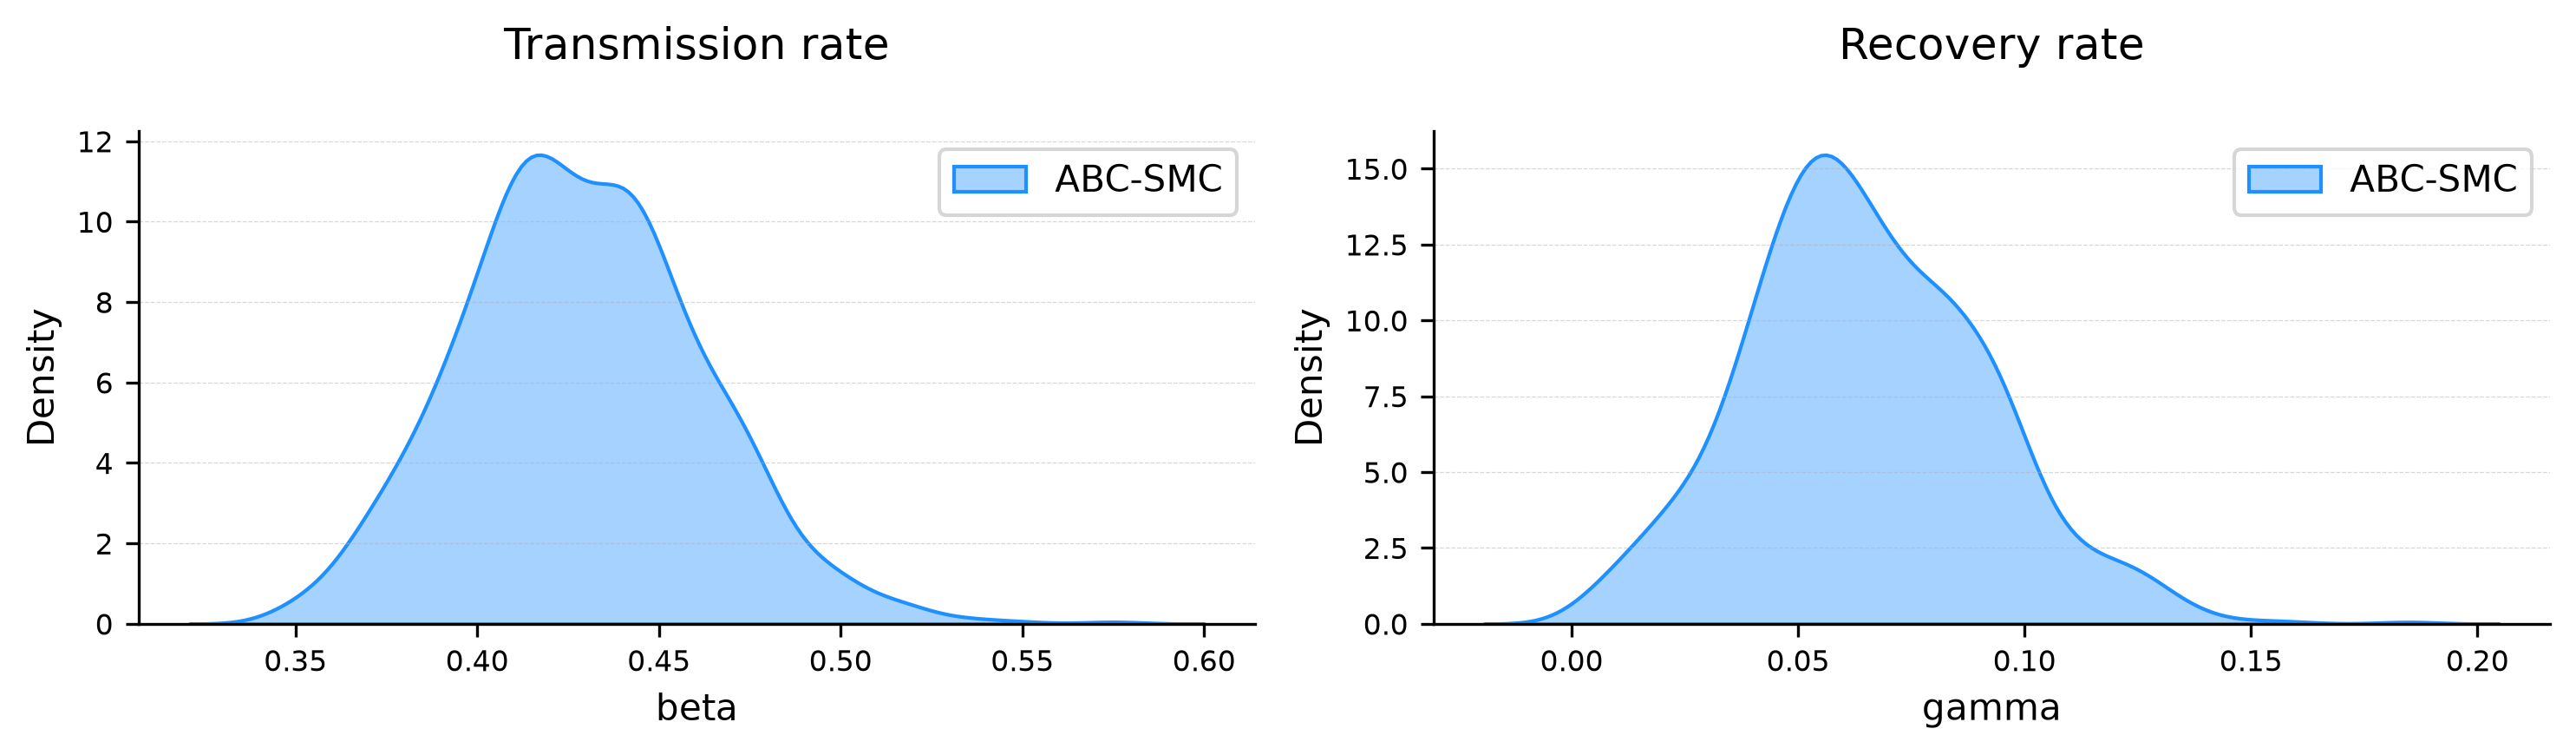

In [77]:
# RMSE Posterior Distributions
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 3), dpi=300)
plot_posterior_distribution(results_rmse.get_posterior_distribution(), "beta", ax=axes[0], kind="kde", title="Transmission rate", prior_range=False, label="ABC-SMC")
axes[0].legend()    

plot_posterior_distribution(results_rmse.get_posterior_distribution(), "gamma", ax=axes[1], kind="kde", title="Recovery rate", prior_range=False, label="ABC-SMC")
axes[1].legend()

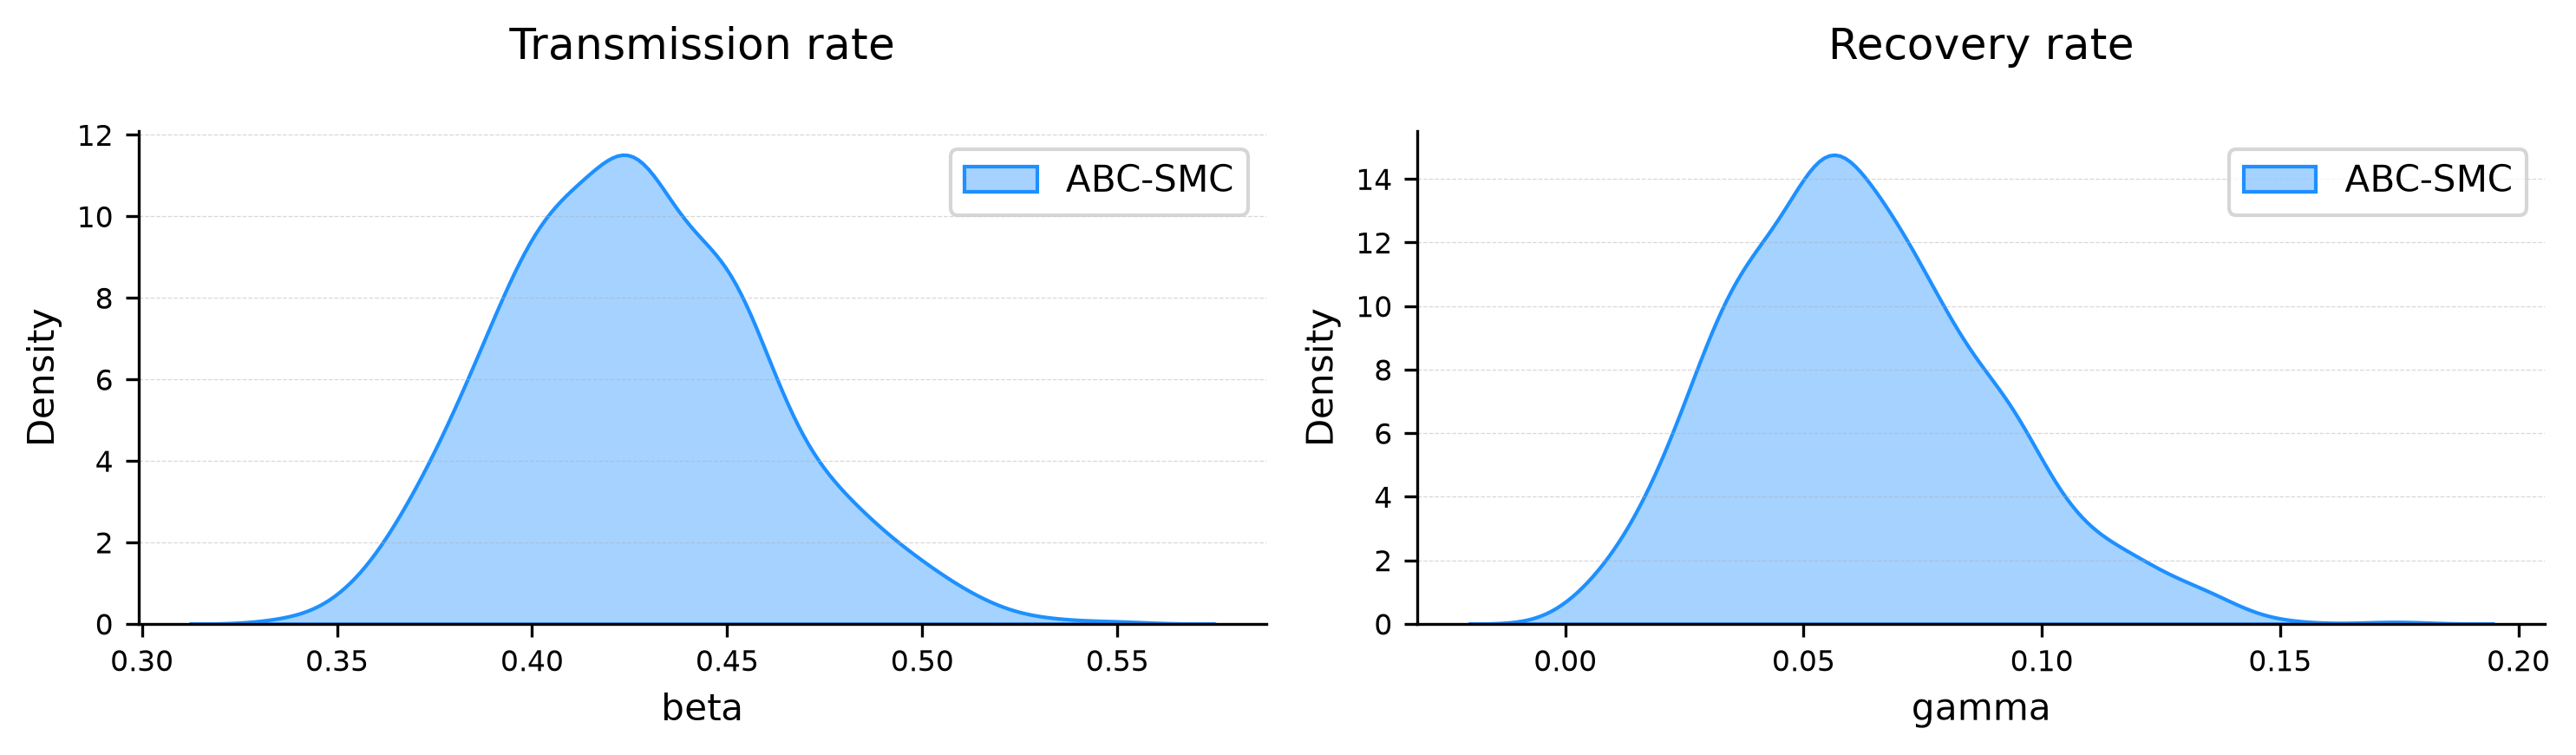

In [78]:
# WMAPE Posterior Distributions
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 3), dpi=300)
plot_posterior_distribution(results_wmape.get_posterior_distribution(), "beta", ax=axes[0], kind="kde", title="Transmission rate", prior_range=False, label="ABC-SMC")
axes[0].legend()    

plot_posterior_distribution(results_wmape.get_posterior_distribution(), "gamma", ax=axes[1], kind="kde", title="Recovery rate", prior_range=False, label="ABC-SMC")
axes[1].legend()

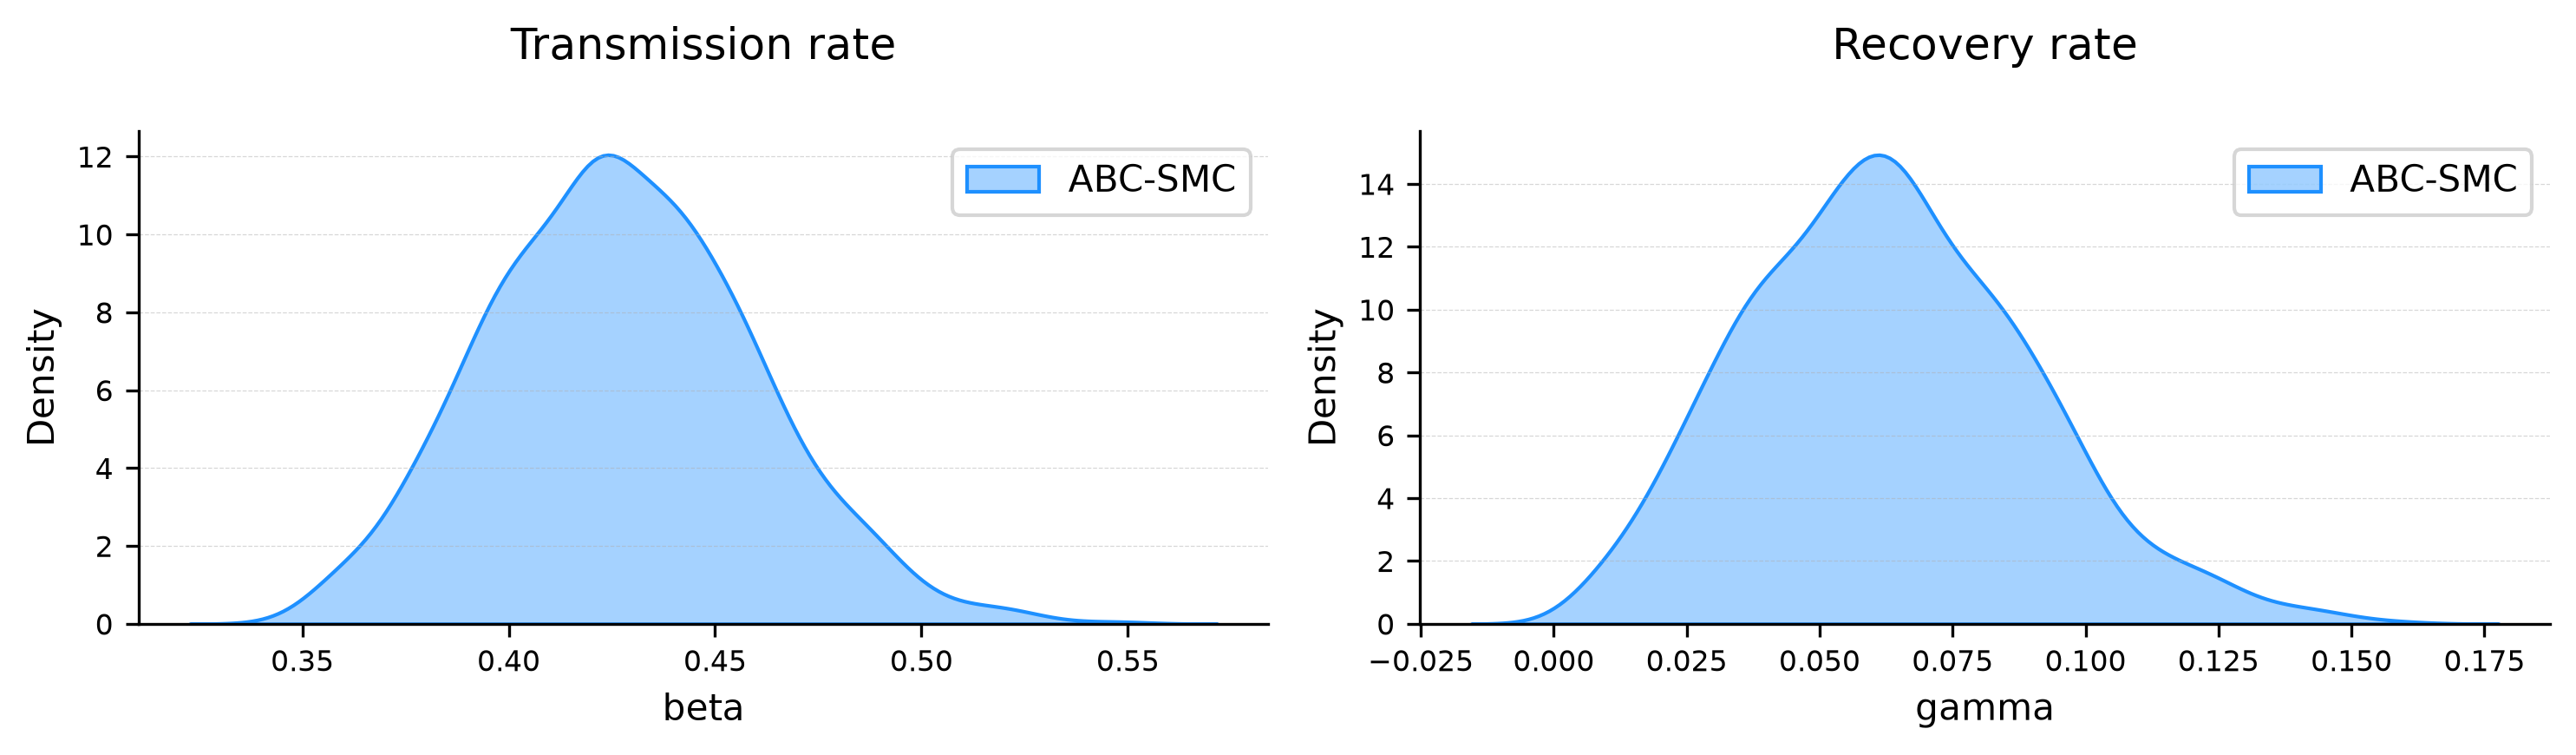

In [79]:
# MAE Posterior Distributions
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 3), dpi=300)
plot_posterior_distribution(results_mae.get_posterior_distribution(), "beta", ax=axes[0], kind="kde", title="Transmission rate", prior_range=False, label="ABC-SMC")
axes[0].legend()    

plot_posterior_distribution(results_mae.get_posterior_distribution(), "gamma", ax=axes[1], kind="kde", title="Recovery rate", prior_range=False, label="ABC-SMC")
axes[1].legend()

# ESS

In [80]:
def weighted_ess_test(generation, smc):
    weights = smc.weights[generation]
    w = weights / np.sum(weights)
    ess = 1 / np.sum(w**2)
    return ess

In [81]:
print(f'RMSE')
for i in range(9):
    ess = weighted_ess_test(i, results_rmse)
    print(f"The ESS for RMSE, generation {i} is: {ess:.2f}")

RMSE
The ESS for RMSE, generation 0 is: 1000.00
The ESS for RMSE, generation 1 is: 707.07
The ESS for RMSE, generation 2 is: 606.95
The ESS for RMSE, generation 3 is: 573.65
The ESS for RMSE, generation 4 is: 675.58
The ESS for RMSE, generation 5 is: 752.93
The ESS for RMSE, generation 6 is: 795.83
The ESS for RMSE, generation 7 is: 849.36
The ESS for RMSE, generation 8 is: 889.98


In [82]:
print(f'WMAPE')
for i in range(9):
    ess = weighted_ess_test(i, results_wmape)
    print(f"The ESS for RMSE, generation {i} is: {ess:.2f}")

WMAPE
The ESS for RMSE, generation 0 is: 1000.00
The ESS for RMSE, generation 1 is: 626.45
The ESS for RMSE, generation 2 is: 601.27
The ESS for RMSE, generation 3 is: 549.87
The ESS for RMSE, generation 4 is: 603.86
The ESS for RMSE, generation 5 is: 701.41
The ESS for RMSE, generation 6 is: 753.64
The ESS for RMSE, generation 7 is: 810.55
The ESS for RMSE, generation 8 is: 855.65


In [83]:
print(f'MAE')
for i in range(9):
    ess = weighted_ess_test(i, results_mae)
    print(f"The ESS for RMSE, generation {i} is: {ess:.2f}")

MAE
The ESS for RMSE, generation 0 is: 1000.00
The ESS for RMSE, generation 1 is: 607.21
The ESS for RMSE, generation 2 is: 581.37
The ESS for RMSE, generation 3 is: 550.04
The ESS for RMSE, generation 4 is: 602.84
The ESS for RMSE, generation 5 is: 693.40
The ESS for RMSE, generation 6 is: 751.84
The ESS for RMSE, generation 7 is: 810.67
The ESS for RMSE, generation 8 is: 864.00


# Distance Distributions

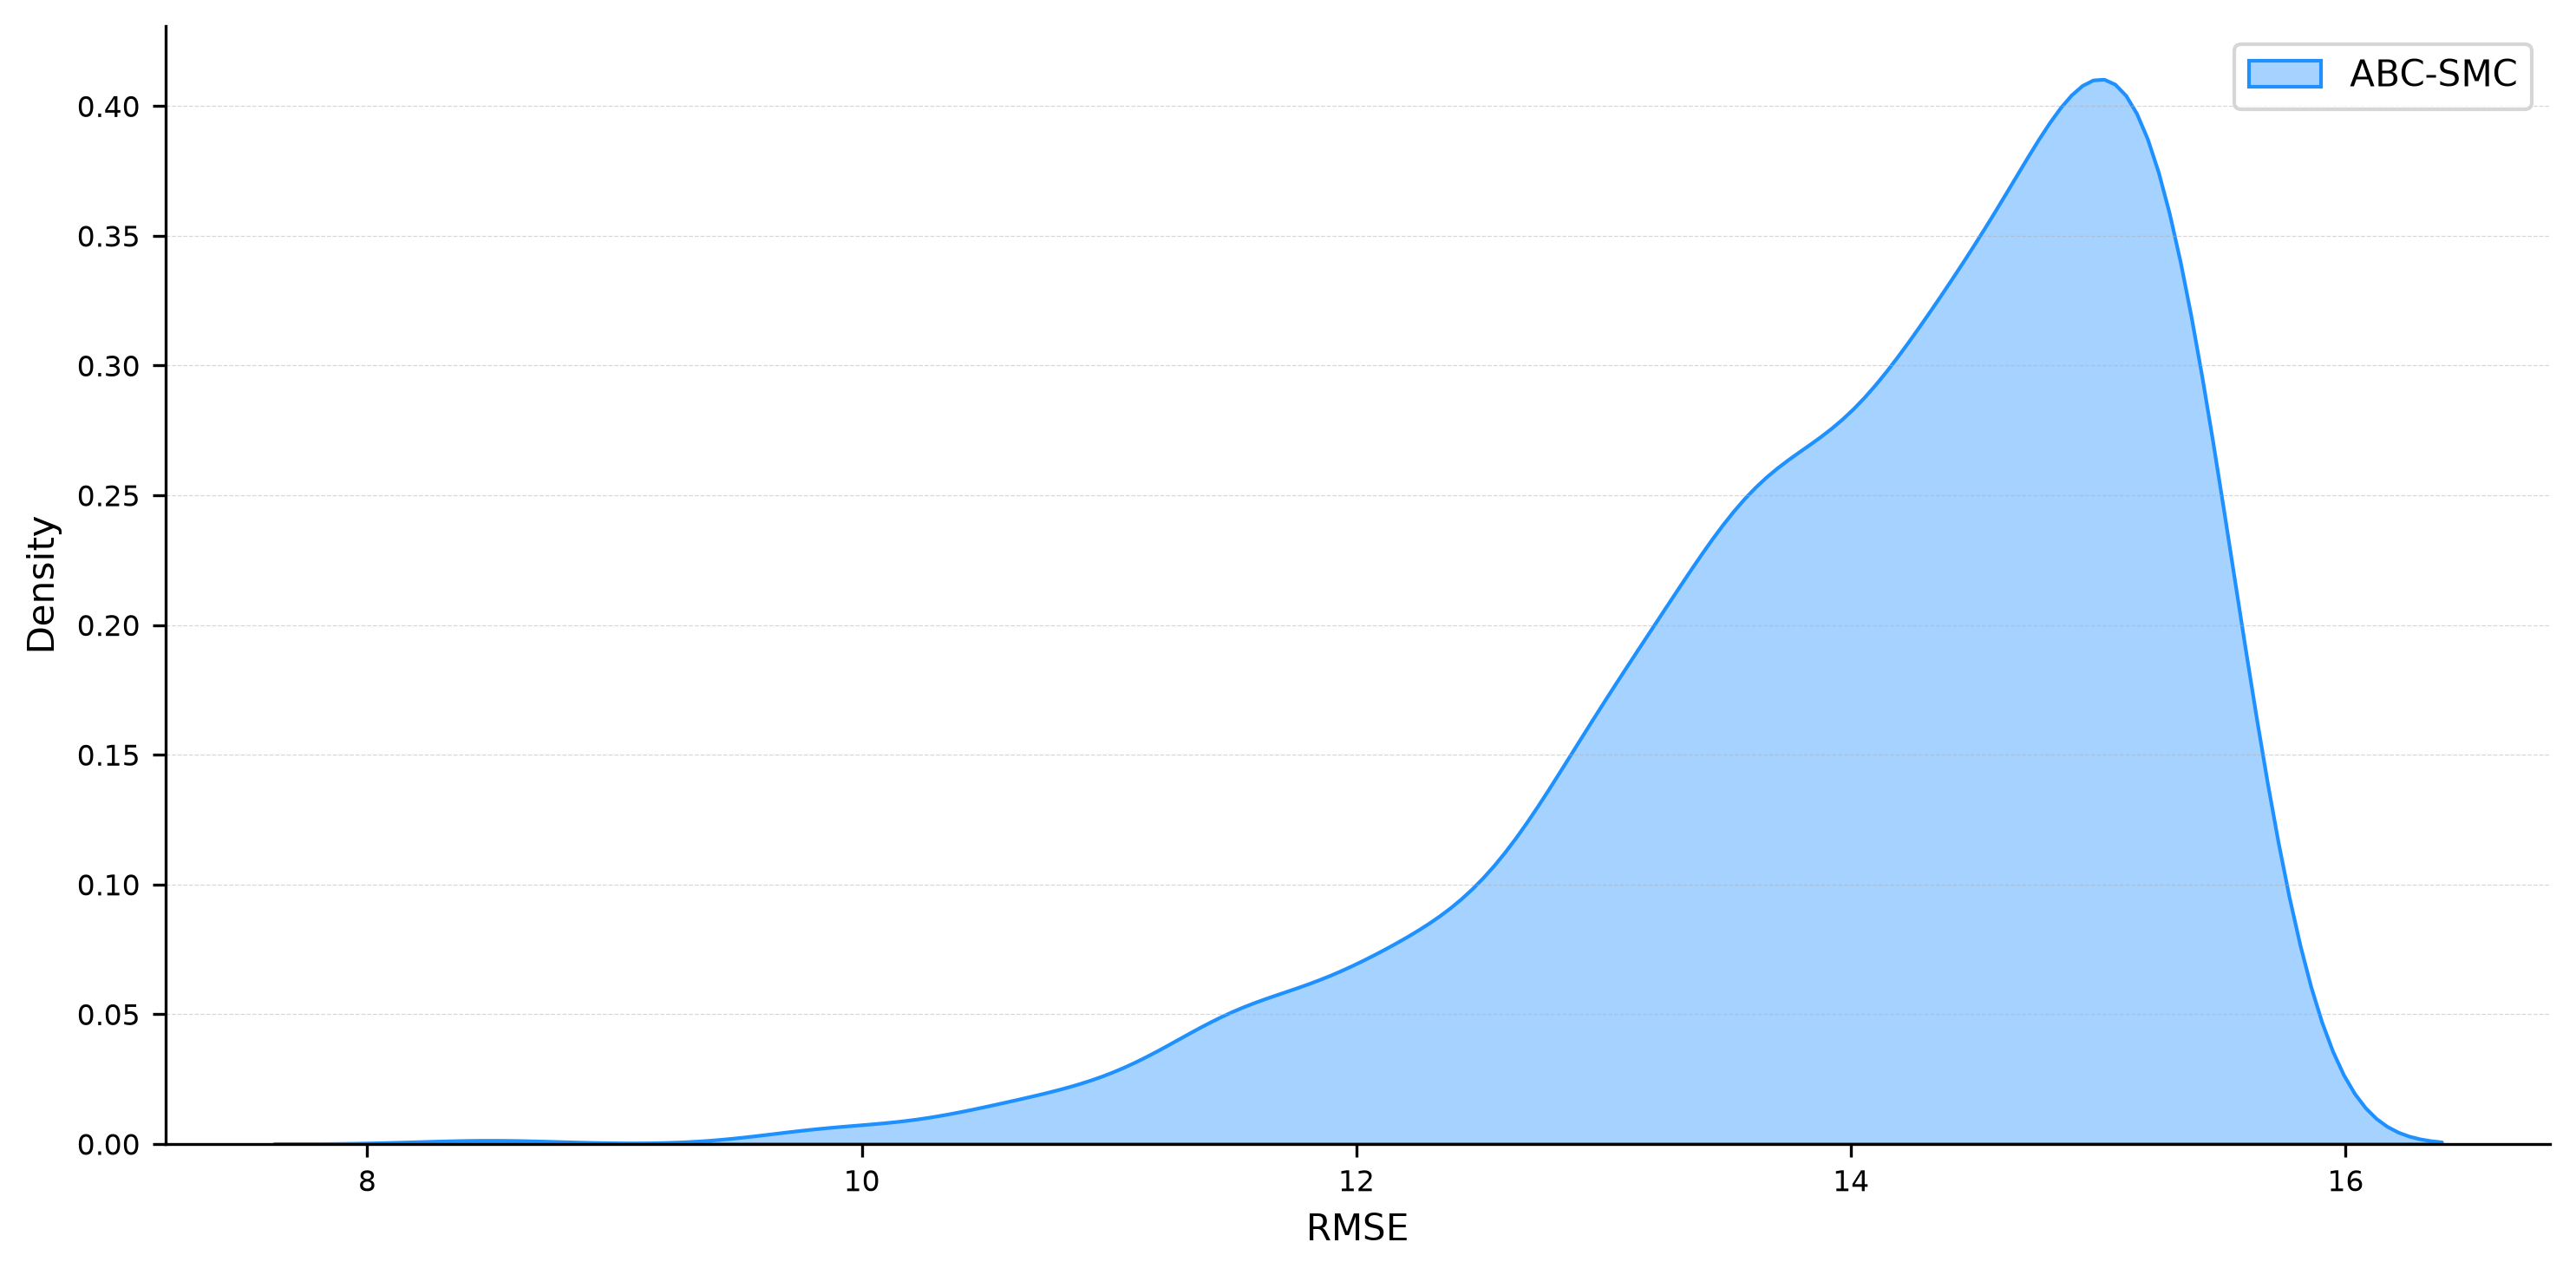

In [84]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=300)
plot_distance_distribution(results_rmse.get_distances(), ax=ax, kind="kde", label="ABC-SMC", xlabel="RMSE")
ax.legend()

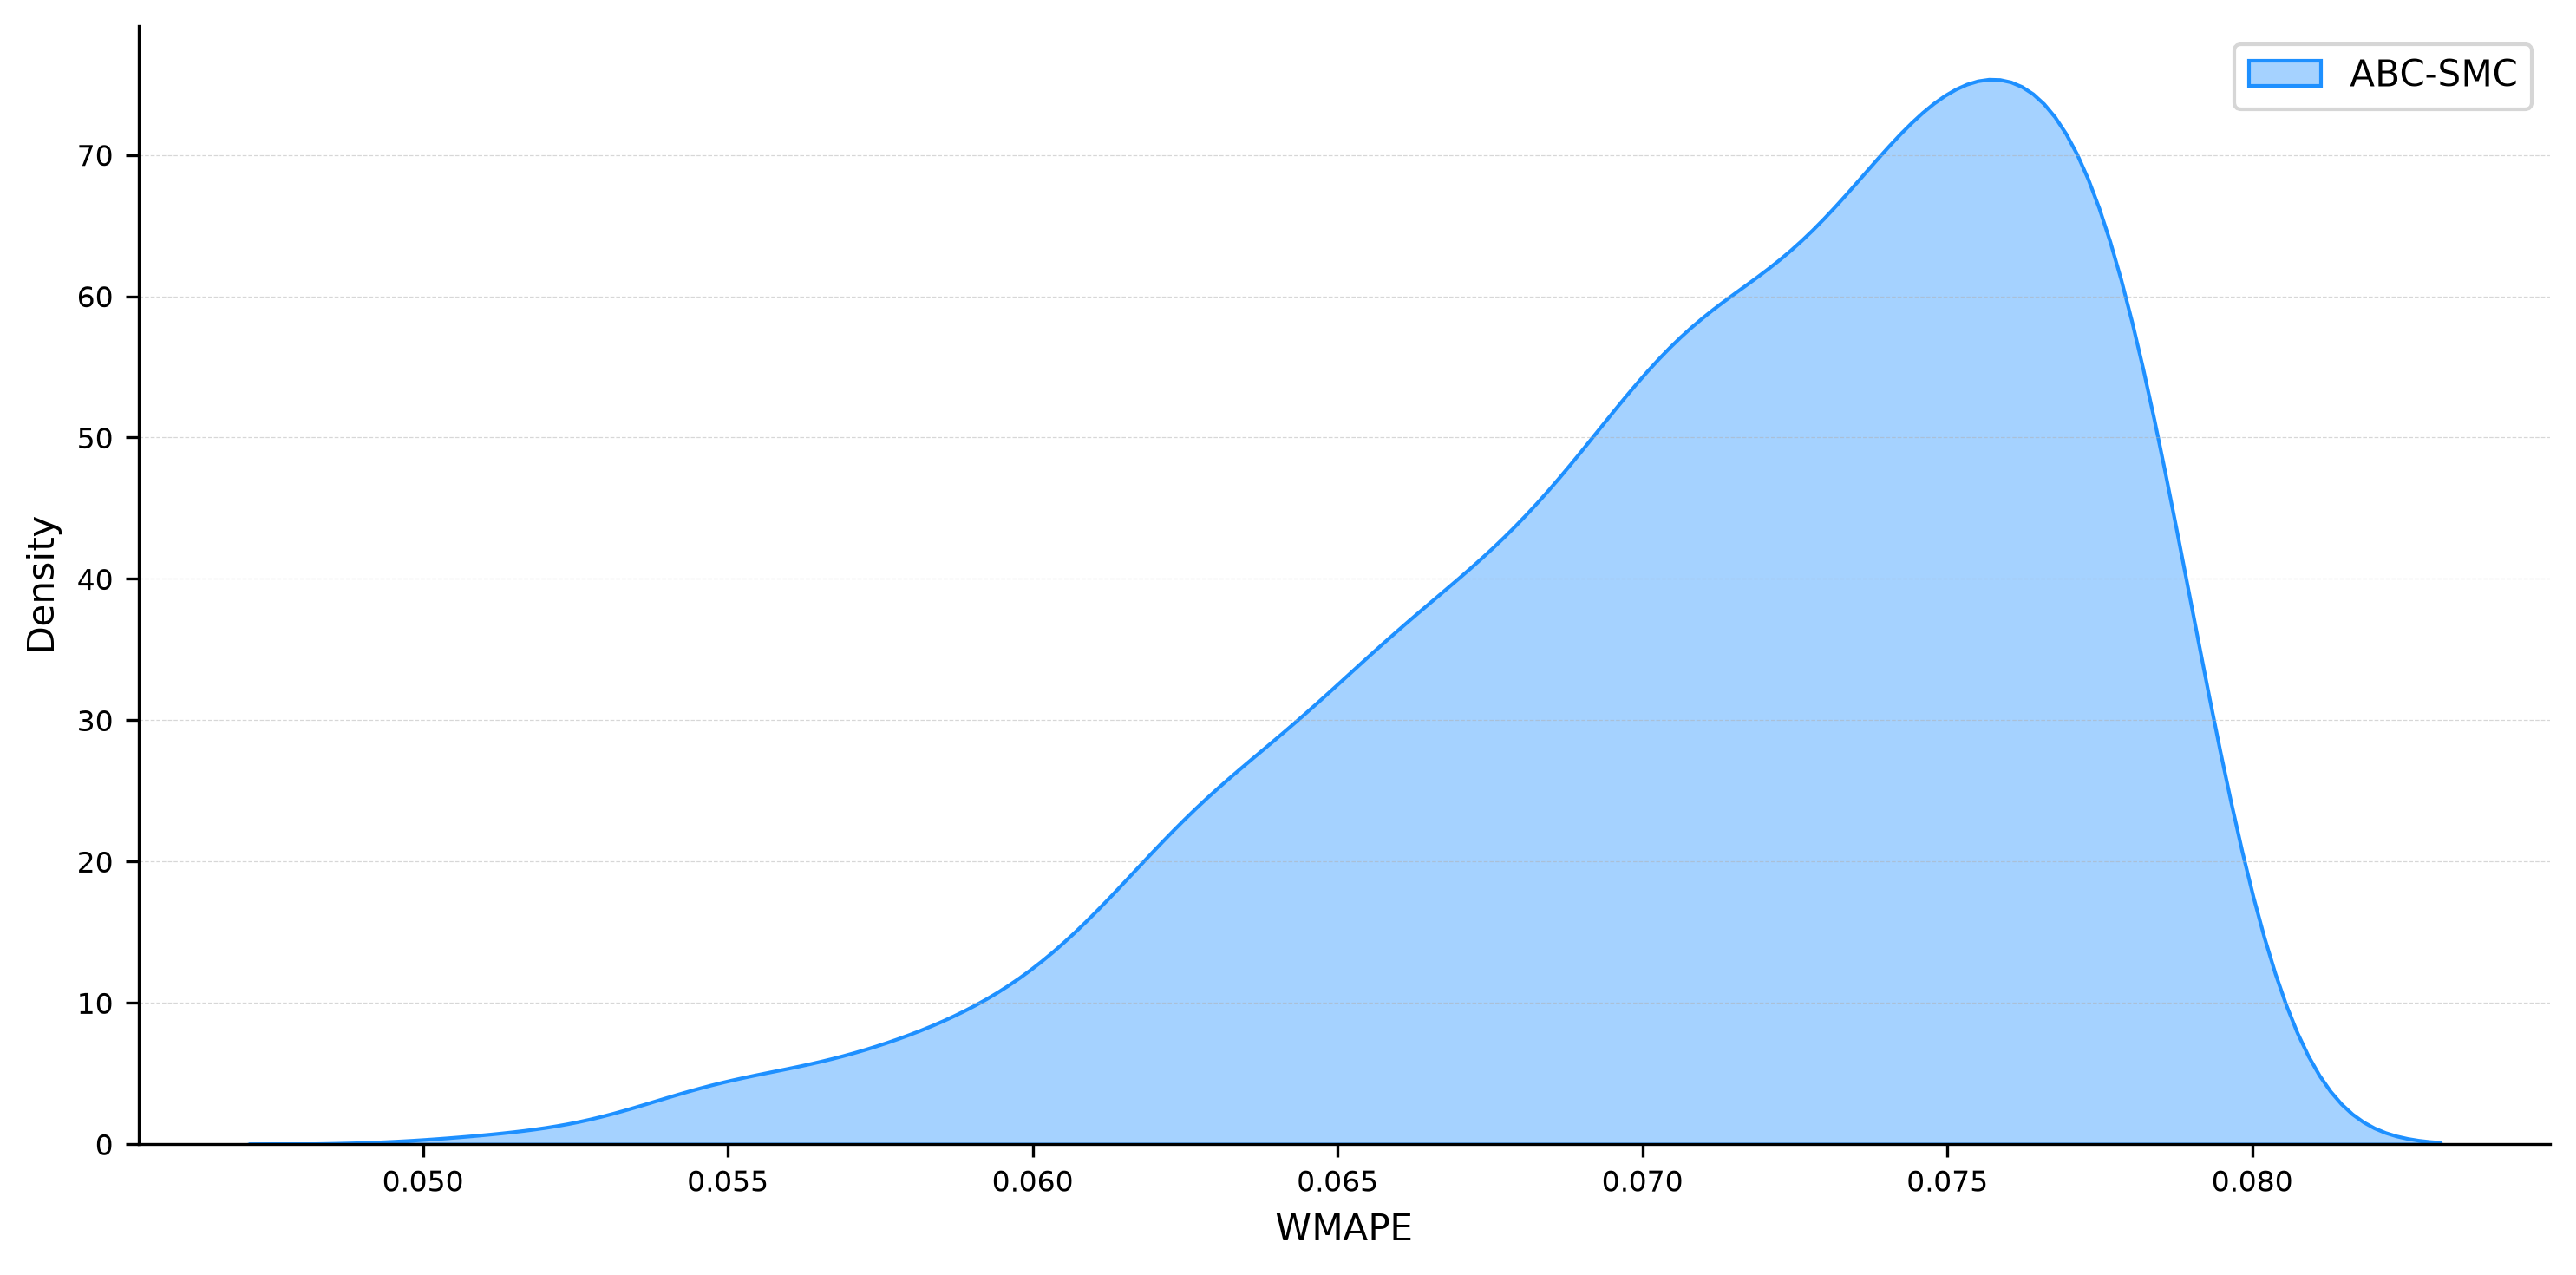

In [85]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=300)
plot_distance_distribution(results_wmape.get_distances(), ax=ax, kind="kde", label="ABC-SMC", xlabel="WMAPE")
ax.legend()

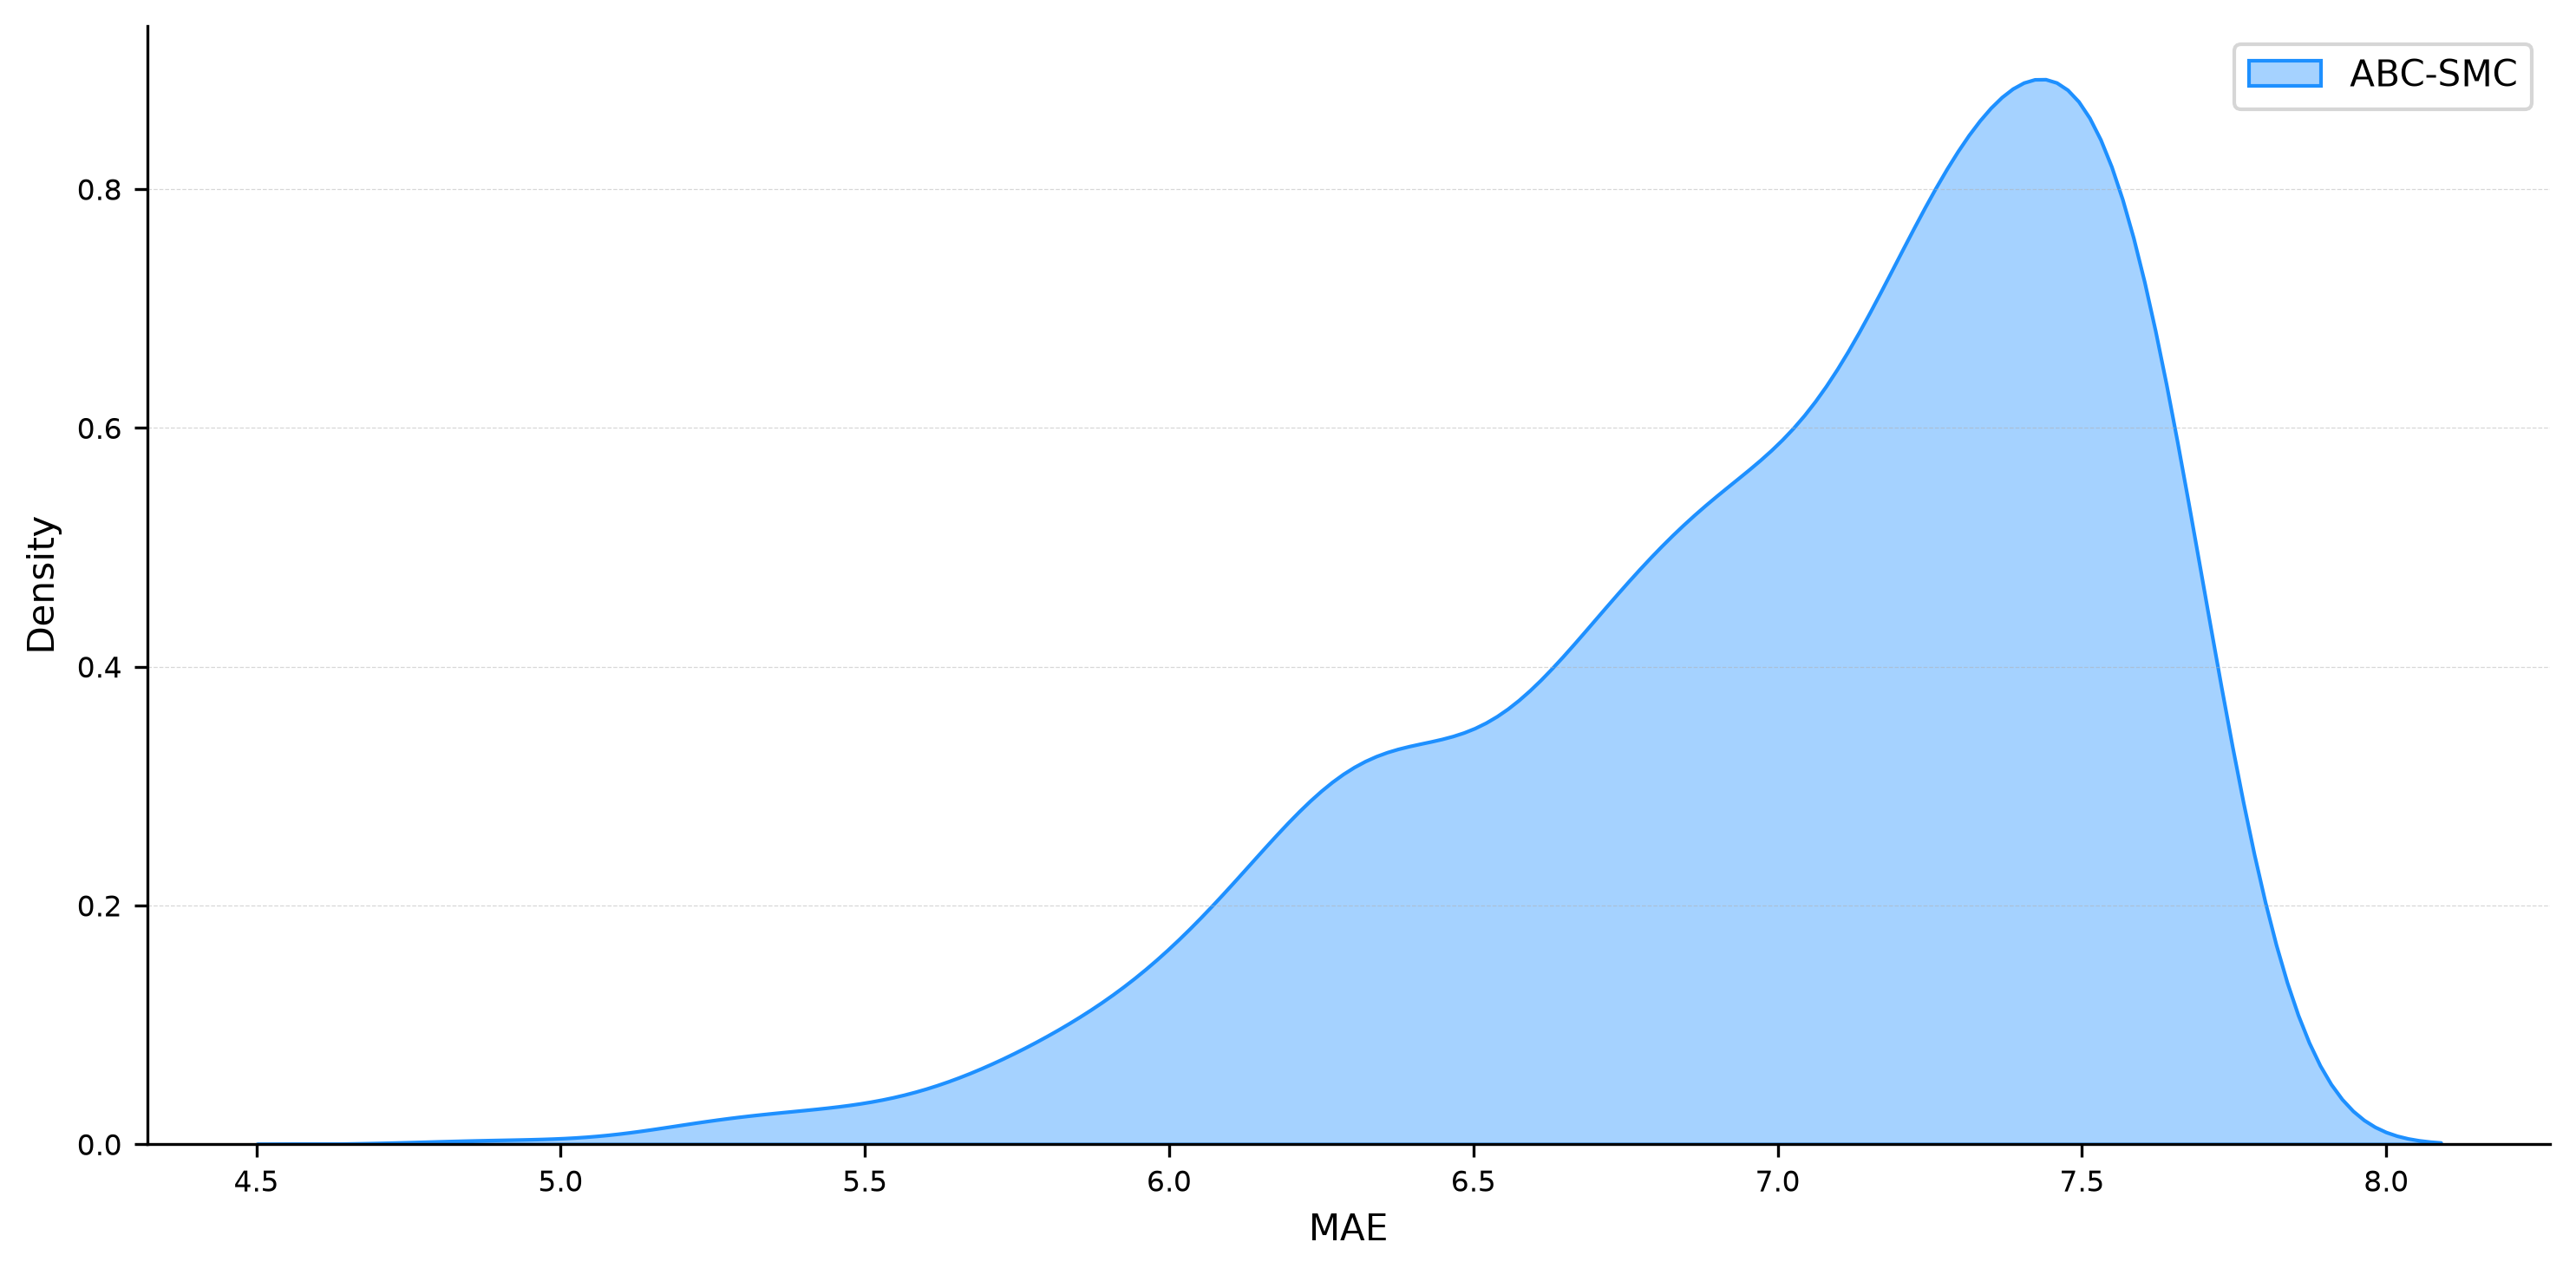

In [86]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=300)
plot_distance_distribution(results_mae.get_distances(), ax=ax, kind="kde", label="ABC-SMC", xlabel="MAE")
ax.legend()